# Time Series and Forecasting
## Anthony Kamau

In [ ]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pylab as pl
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap
%matplotlib inline 
import math

In [3]:
oil_data = pd.read_csv("oil.csv", header=0, quotechar='"', sep=',', na_values=['na', '-', '.',''], low_memory=False)
oil_data.head(10)

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81
8,2013-01-11,93.60
9,2013-01-14,94.27


In [4]:
oil_data.dropna(inplace=True)
oil_data.head(10)

,date,dcoilwtico
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81
8,2013-01-11,93.60
9,2013-01-14,94.27
10,2013-01-15,93.26


## Explore the data

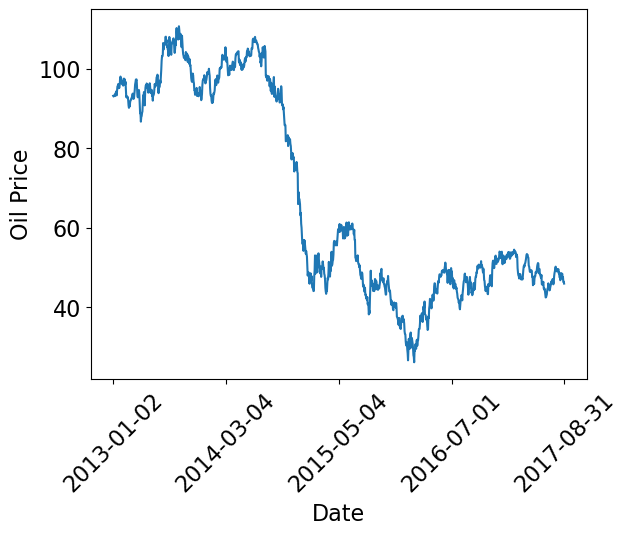

In [5]:
# Use scatter plot to plot the 'Oil Price' against the 'Date'
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots()

# Plot the data as scatter plot
start = 0
limit = len(oil_data)
end = start + limit - 1
ax.plot(oil_data.date[start:end], oil_data.dcoilwtico[start:end], '-')

# Changing the labels on the x-axis
x = [oil_data.date.iloc[start], oil_data.date.iloc[start + math.floor(limit / 4)], \
     oil_data.date.iloc[start + math.floor(limit / 2)], oil_data.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data.date.iloc[end]]
ax.set_xticks(x)
plt.xticks(rotation = 45)

# put the label for the x-axis 'Date' and for the y-axis 'Oil Price'
ax.set(xlabel='Date', ylabel='Oil Price')
plt.savefig("oilData.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Look at the details using a smaller time period

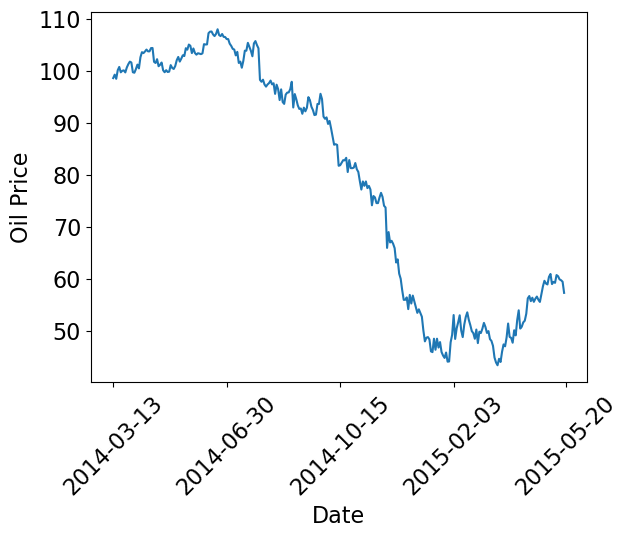

In [6]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots()
start = 300
limit = 300
end = start + limit - 1
ax.plot(oil_data.date[start:end], oil_data.dcoilwtico[start:end], '-')
x = [oil_data.date.iloc[start], oil_data.date.iloc[start + math.floor(limit / 4)], \
     oil_data.date.iloc[start + math.floor(limit / 2)], oil_data.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data.date.iloc[end]]
ax.set_xticks(x)
plt.xticks(rotation = 45)
ax.set(xlabel='Date', ylabel='Oil Price')
plt.savefig("oilData_300.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Depicting the trend of the oil price using Semi-average

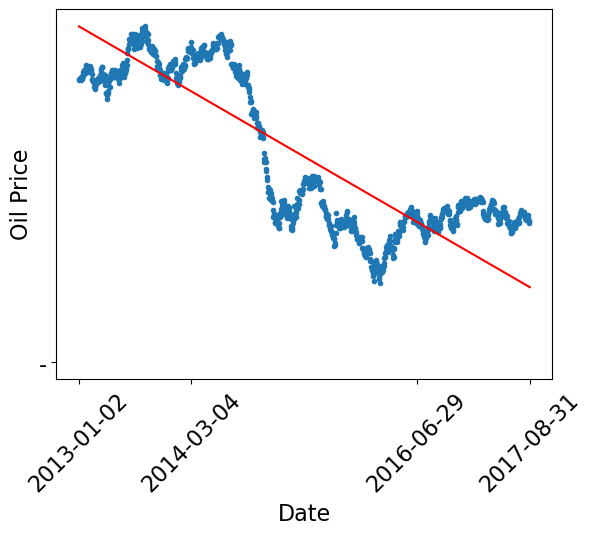

In [9]:
m1 = oil_data.dcoilwtico[0:math.floor(len(oil_data)/2)].mean()
m2 = oil_data.dcoilwtico[math.floor(len(oil_data)/2)+1:len(oil_data)].mean()

start = 0 
first = math.floor(len(oil_data)/4)
second = 3 * math.floor(len(oil_data)/4)
limit = len(oil_data)
end = start + limit - 1
y_start = (m2 - m1) / (second - first) * (start - first) + m1
y_end = (m2 - m1) / (second - first) * (end - first) + m1
semi_avg = [y_start, m1, m2, y_end]
x = [oil_data.date.iloc[start], oil_data.date.iloc[first], oil_data.date.iloc[second], oil_data.date.iloc[end]]
fig, ax = plt.subplots()
ax.plot(oil_data.date[start:end], oil_data.dcoilwtico[start:end], '.')
ax.plot(x, semi_avg, 'r', '-')
ax.set_xticks(x)
plt.xticks(rotation = 45)
ax.set(xlabel='Date', ylabel='Oil Price')
plt.savefig("oilData_SemiAverage.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Depicting the trend of the oil trend using Moving-average
- First: using rolling(window = 50)
- Second: using rolling(window = 50, min_periods = 1)

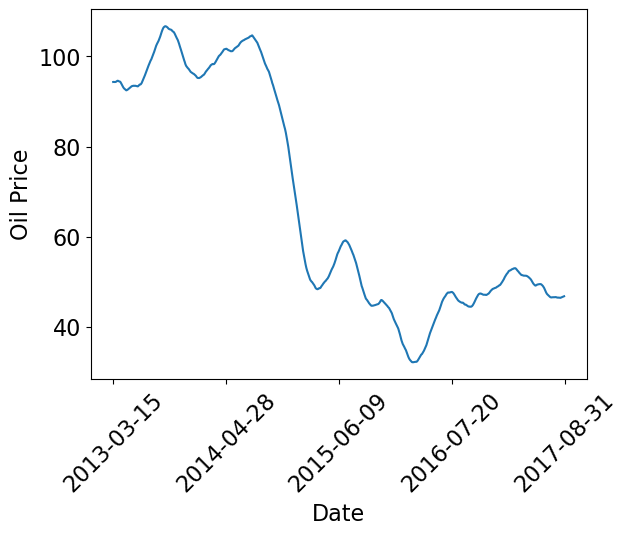

In [10]:
# TODO: use pd.DataFrame.rolling(window = ma_win_size), comment on the output
ma_win_size = 50
oil_data_ma = oil_data.copy()
oil_data_ma['ma_dcoilwtico'] = oil_data_ma['dcoilwtico'].rolling(window = ma_win_size).mean()


start = ma_win_size
limit = len(oil_data_ma) - ma_win_size
end = start + limit - 1

fig, ax = plt.subplots()

ax.plot(oil_data_ma.date[start:end], oil_data_ma.ma_dcoilwtico[start:end], '-')
x = [oil_data_ma.date.iloc[start], oil_data_ma.date.iloc[start + math.floor(limit / 4)], \
     oil_data_ma.date.iloc[start + math.floor(limit / 2)], oil_data_ma.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data_ma.date.iloc[end]]
ax.set_xticks(x)
plt.xticks(rotation = 45)
ax.set(xlabel='Date', ylabel='Oil Price')

plt.savefig("oilData_MovingAverageNA.pdf", format="pdf", bbox_inches="tight")
plt.show()

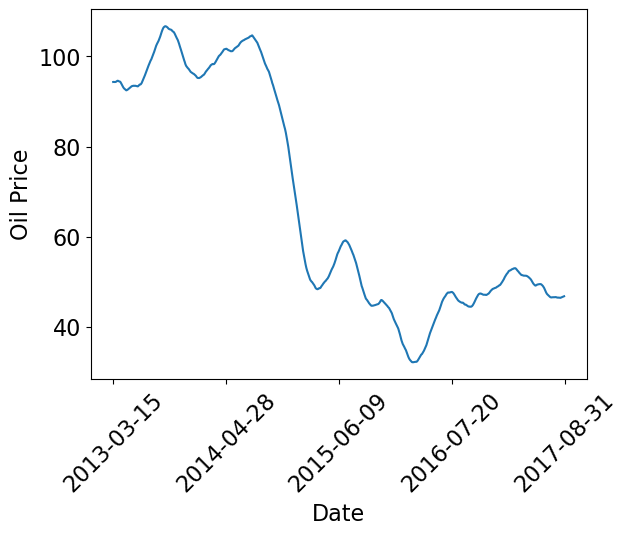

In [12]:
ma_win_size = 50
oil_data_ma['ma_dcoilwtico'] = oil_data['dcoilwtico'].rolling(window = ma_win_size, min_periods = 1).mean()


start = ma_win_size
limit = len(oil_data_ma) - ma_win_size
end = start + limit - 1

fig, ax = plt.subplots()

ax.plot(oil_data_ma.date[start:end], oil_data_ma.ma_dcoilwtico[start:end], '-')
x = [oil_data_ma.date.iloc[start], oil_data_ma.date.iloc[start + math.floor(limit / 4)], \
     oil_data_ma.date.iloc[start + math.floor(limit / 2)], oil_data_ma.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data_ma.date.iloc[end]]
ax.set_xticks(x)
plt.xticks(rotation = 45)
ax.set(xlabel='Date', ylabel='Oil Price')

plt.savefig("oilData_MovingAverage.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Showing part of the the data next to the plot

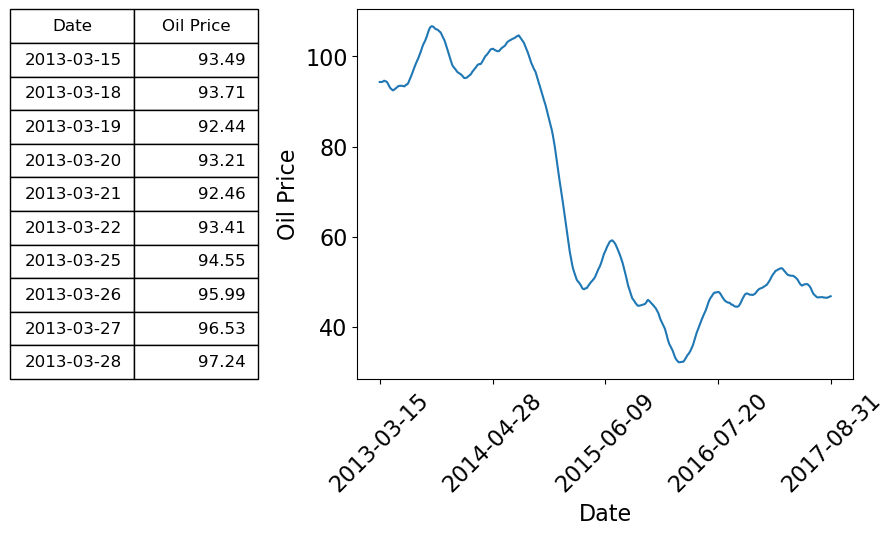

In [13]:
# Display part of the data next to figure
oil_data_new = oil_data_ma
start = ma_win_size
limit = len(oil_data_new) - ma_win_size - 1
end = start + limit

fig, ax = plt.subplots()

# TODO: Plot the trend of the data that was generated using moving average technique
# in the previous cell

ax.plot(oil_data_new.date[start:end], oil_data_new.ma_dcoilwtico[start:end], '-')
x = [oil_data_new.date.iloc[start], oil_data_new.date.iloc[start + math.floor(limit / 4)], \
     oil_data_new.date.iloc[start + math.floor(limit / 2)], oil_data_new.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data_new.date.iloc[end]]
ax.set_xticks(x)
plt.xticks(rotation = 45)

# Now, we plot a snippet of the data next to the figure
a = oil_data_new.date[start:start + 10]
b = [round(num, 2) for num in oil_data_new.dcoilwtico[start:start + 10]]
data = [list(a), list(b)]
numpy_array = np.array(data)
data = numpy_array.T.tolist()
tbl = plt.table(cellText = data,
          colLabels=['Date', 'Oil Price'],
          loc='left',
          bbox=[-0.7, 0, 0.5, 1])

ax.set(xlabel='Date', ylabel='Oil Price')
plt.savefig("oilData_MovingAverageWData.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Depicting the trend of the oil trend using Linear Regression

In [16]:
# function for computing linear regression coefficients
def mySimpleLinearRegression(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    x_diff = x - x_mean
    y_diff = y - y_mean

    coef = sum(x_diff * y_diff) / sum(x_diff ** 2)
    intercept = y_mean - coef * x_mean
    return (intercept , coef)



Using the function in the previous cell:
intercept =  67.71436595744682 
Coef. =  -0.06330406203004589


Using the scikit learn package:
Intercept: 67.71436595744682
Coef.: -0.06330406203004604


[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Oil Price')]

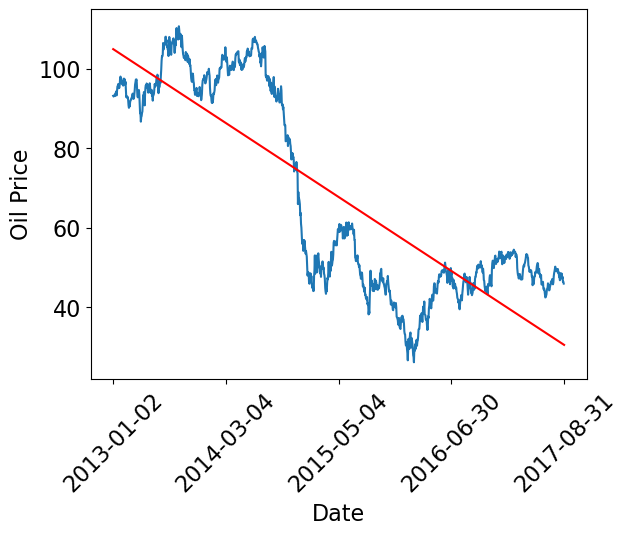

In [18]:
# Preprocess the dataframe by removing the missing values and re-indexing the data

oil_data_nona = oil_data.dropna()
oil_data_nona.reset_index(drop=True, inplace=True)
offset = math.floor(len(oil_data_nona) / 2)
oil_data_nona['x'] = oil_data_nona.index - offset

# compute the linear regression parameters uisng the function in the previous cell

xc = np.array(oil_data_nona.x)
yc = np.array(oil_data_nona.dcoilwtico)
a0, a1 = mySimpleLinearRegression(xc, yc)

print('\n\nUsing the function in the previous cell:')
print('intercept = ', a0, '\nCoef. = ', a1)


# compute the linear regression parameters uisng the scikit learn LinearRegression class

myLR = LinearRegression()
myLR.fit(xc.reshape(len(xc),1), yc.reshape(len(yc),1))

print('\n\nUsing the scikit learn package:')
print( "Intercept:", myLR.intercept_[0])
print( "Coef.:", myLR.coef_[0][0])


# Plot the data and the line generated by linear regression

start = 0
limit = len(oil_data_nona) - 1
end = start + limit

fig, ax = plt.subplots()

ax.plot(oil_data_nona.x[start:end], oil_data_nona.dcoilwtico[start:end], '-')
x = [oil_data_nona.x.iloc[start], \
     oil_data_nona.x.iloc[start + math.floor(limit / 4)], \
     oil_data_nona.x.iloc[start + math.floor(limit / 2)], \
     oil_data_nona.x.iloc[start + math.floor(3 * limit / 4)], \
     oil_data_nona.x.iloc[end]]
xticks = [oil_data_nona.date.iloc[start], \
     oil_data_nona.date.iloc[start + math.floor(limit / 4)], \
     oil_data_nona.date.iloc[start + math.floor(limit / 2)], \
     oil_data_nona.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data_nona.date.iloc[end]]
plt.xticks(x, xticks)
plt.xticks(rotation = 45)

model = [a0 + a1 * x for x in oil_data_nona.x]
plt.plot(oil_data_nona.x, model, 'r');

ax.set(xlabel='Date', ylabel='Oil Price')

## Depicting the trend of the oil trend using Exponential Smoothing

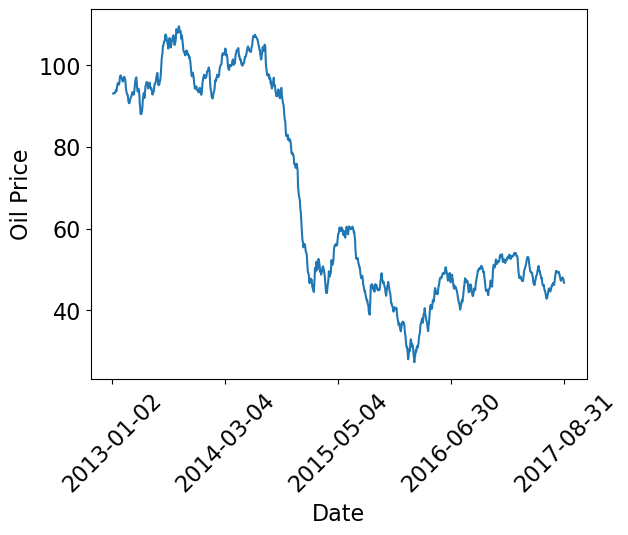

In [ ]:
# Applying the exponential Smoothing on the data and display the resulting time series using different values for alpha [alpha = 0.5]

oil_data_nona = oil_data.dropna()
oil_data_nona.reset_index(drop=True, inplace=True)

alpha = 0.5
exp_smoothing = np.zeros(len(oil_data_nona) - 1)
exp_smoothing[0] = exp_smoothing[1] = np.nan
exp_smoothing[2] = alpha * oil_data_nona.loc[0, 'dcoilwtico'] \
                + (1 - alpha) * oil_data_nona.loc[1, 'dcoilwtico'] 
for i in range(2, len(oil_data_nona) - 2):
  exp_smoothing[i+1] = alpha * oil_data_nona.loc[i, 'dcoilwtico'] \
                + (1 - alpha) * exp_smoothing[i]

start = 0
limit = len(oil_data_nona) - 1
end = start + limit

fig, ax = plt.subplots()

ax.plot(oil_data_nona.date[start:end], exp_smoothing, '-')
x = [oil_data_nona.date.iloc[start], \
     oil_data_nona.date.iloc[start + math.floor(limit / 4)], \
     oil_data_nona.date.iloc[start + math.floor(limit / 2)], \
     oil_data_nona.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data_nona.date.iloc[end]]
ax.set_xticks(x)
plt.xticks(rotation = 45)

ax.set(xlabel='Date', ylabel='Oil Price')
plt.savefig("oilData_ExpSmoothing.pdf", format="pdf", bbox_inches="tight")
plt.show()

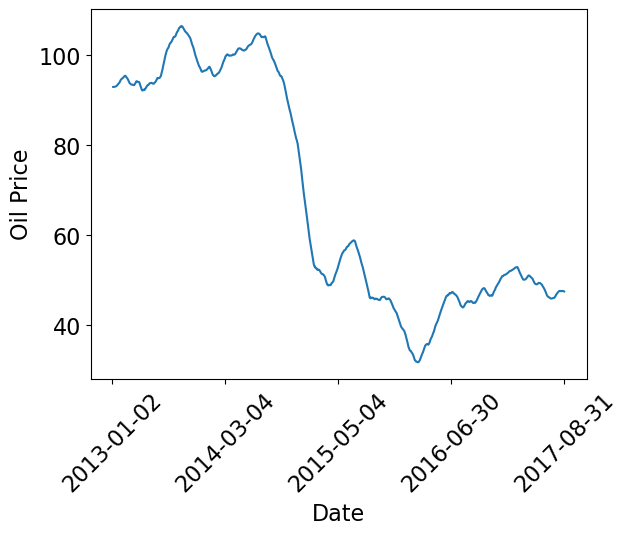

In [24]:
# Applying the exponential Smoothing on the data and display the resulting time series using different values for alpha [alpha = 0.05] 

oil_data_nona = oil_data.dropna()
oil_data_nona.reset_index(drop=True, inplace=True)

alpha = 0.05
exp_smoothing = np.zeros(len(oil_data_nona) - 1)
exp_smoothing[0] = exp_smoothing[1] = np.nan
exp_smoothing[2] = alpha * oil_data_nona.loc[0, 'dcoilwtico'] \
                + (1 - alpha) * oil_data_nona.loc[1, 'dcoilwtico'] 
for i in range(2, len(oil_data_nona) - 2):
  exp_smoothing[i+1] = alpha * oil_data_nona.loc[i, 'dcoilwtico'] \
                + (1 - alpha) * exp_smoothing[i]

start = 0
limit = len(oil_data_nona) - 1
end = start + limit

fig, ax = plt.subplots()

ax.plot(oil_data_nona.date[start:end], exp_smoothing, '-')
x = [oil_data_nona.date.iloc[start], \
     oil_data_nona.date.iloc[start + math.floor(limit / 4)], \
     oil_data_nona.date.iloc[start + math.floor(limit / 2)], \
     oil_data_nona.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data_nona.date.iloc[end]]
ax.set_xticks(x)
plt.xticks(rotation = 45)

ax.set(xlabel='Date', ylabel='Oil Price')
plt.savefig("oilData_ExpSmoothing.pdf", format="pdf", bbox_inches="tight")
plt.show()

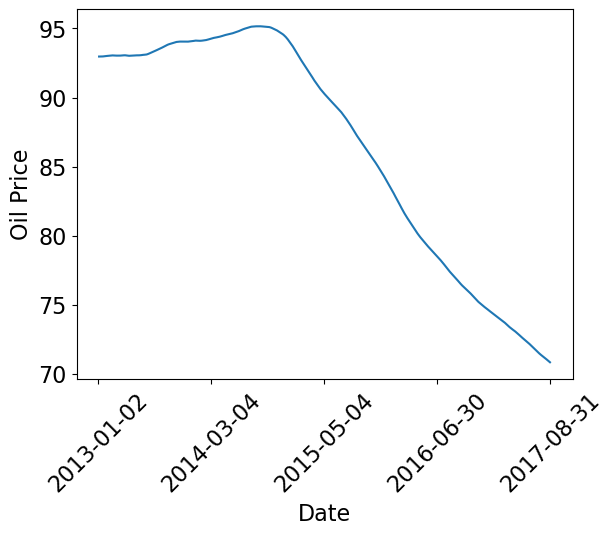

In [25]:
# Applying the exponential Smoothing on the data and display the resulting time series using different values for alpha [alpha = 0.001] 

oil_data_nona = oil_data.dropna()
oil_data_nona.reset_index(drop=True, inplace=True)

alpha = 0.001
exp_smoothing = np.zeros(len(oil_data_nona) - 1)
exp_smoothing[0] = exp_smoothing[1] = np.nan
exp_smoothing[2] = alpha * oil_data_nona.loc[0, 'dcoilwtico'] \
                + (1 - alpha) * oil_data_nona.loc[1, 'dcoilwtico'] 
for i in range(2, len(oil_data_nona) - 2):
  exp_smoothing[i+1] = alpha * oil_data_nona.loc[i, 'dcoilwtico'] \
                + (1 - alpha) * exp_smoothing[i]

start = 0
limit = len(oil_data_nona) - 1
end = start + limit

fig, ax = plt.subplots()

ax.plot(oil_data_nona.date[start:end], exp_smoothing, '-')
x = [oil_data_nona.date.iloc[start], \
     oil_data_nona.date.iloc[start + math.floor(limit / 4)], \
     oil_data_nona.date.iloc[start + math.floor(limit / 2)], \
     oil_data_nona.date.iloc[start + math.floor(3 * limit / 4)], \
     oil_data_nona.date.iloc[end]]
ax.set_xticks(x)
plt.xticks(rotation = 45)

ax.set(xlabel='Date', ylabel='Oil Price')
plt.savefig("oilData_ExpSmoothing.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [27]:
oil_data_nona

,date,dcoilwtico
0,2013-01-02,93.14
1,2013-01-03,92.97
2,2013-01-04,93.12
3,2013-01-07,93.20
4,2013-01-08,93.21
...,...,...
1170,2017-08-25,47.65
1171,2017-08-28,46.40
1172,2017-08-29,46.46
1173,2017-08-30,45.96


# Seasonal Component

In [28]:
oil_data_SC = pd.read_csv("oil.csv", header=0, quotechar='"', sep=',', na_values=['na', '-', '.',''], low_memory=False)

In [29]:
from datetime import datetime

date_str = [oil_data_SC.iloc[i,0] for i in range(len(oil_data_SC))]
date_format = '%Y-%m-%d'
date_obj = [datetime.strptime(d_str, date_format) for d_str in date_str]

In [32]:
oil_data_SC.index = pd.to_datetime(date_obj, format='%y-%m-%d %H:%M:%S')
oil_G = oil_data_SC.groupby(by = [oil_data_SC.index.month, oil_data_SC.index.year]).mean(numeric_only=True)
oil_MM = oil_G.groupby(level = 0).mean()     # Monthly mean over the years
oil_MM

,dcoilwtico
1,64.155993
2,66.100389
3,65.688027
4,68.071807
5,70.228087
6,71.064266
7,70.088496
8,67.747568
9,72.540827
10,70.233523


In [34]:
oil_MM.rename(columns = {'dcoilwtico':'Monthly mean'})

,Monthly mean
1,64.155993
2,66.100389
3,65.688027
4,68.071807
5,70.228087
6,71.064266
7,70.088496
8,67.747568
9,72.540827
10,70.233523


In [35]:
# Now, we compute the seasonal index by dividing the monthly mean over the mean of the means
oil_SI = df_MM/ (oil_MM.mean()) * 100
oil_SI.rename(columns = {'dcoilwtico':'Seasonal Index'})

,Seasonal Index
1,94.826158
2,97.700084
3,97.090589
4,100.613949
5,103.801052
6,105.036972
7,103.594729
8,100.134707
9,107.219412
10,103.809087


# Time Series Decomposition

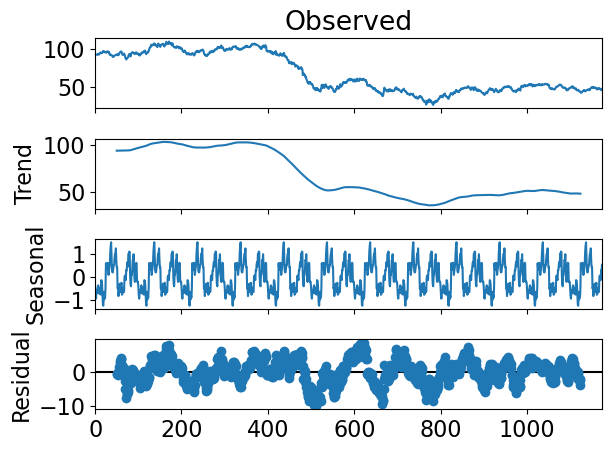

In [36]:
# Apply the Additive time series decomposition on the oil dataset. 

from pandas import Series
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
%matplotlib inline

series = list(oil_data.dcoilwtico.dropna())
result = seasonal_decompose(series, model='additive', period=100)
result.plot()
plt.savefig("oil_price.pdf", format="pdf", bbox_inches="tight")
plt.show()

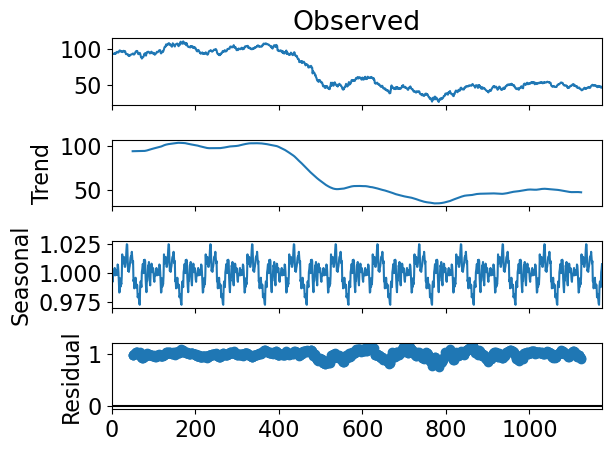

In [37]:
# Apply the Multiplicative time series decomposition on the oil dataset. 

from pandas import Series
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
%matplotlib inline

series = list(oil_data.dcoilwtico.dropna())
result = seasonal_decompose(series, model='multiplicative', period=100)
result.plot()
plt.savefig("oil_price.pdf", format="pdf", bbox_inches="tight")
plt.show()

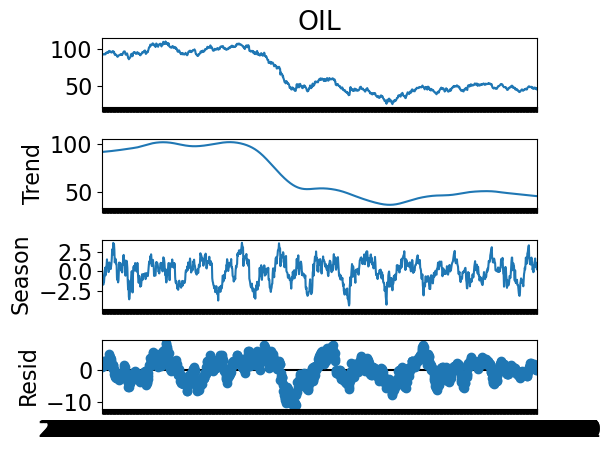

In [38]:
# Apply the STL time series decomposition on the oil dataset. 

from statsmodels.tsa.seasonal import STL

oil_data_new = oil_data.dropna()
dcoilwtico = list(oil_data_new.dcoilwtico)

oil_data_STL = pd.Series(
dcoilwtico, index=oil_data_new.date, name="OIL")

stl = STL(oil_data_STL, period = 100)
res = stl.fit()
fig = res.plot()

# Demand Forecasting

In [39]:
oil_data_FC = pd.read_csv("oil.csv", header=0, quotechar='"', sep=',', na_values=['na', '-', '.',''], low_memory=False)

### Remove the last two weeks of the data and store it as test data

In [41]:
oil_data_FC = oil_data_FC.dropna()
oil_data_FC.reset_index(drop=True, inplace=True)
idx = oil_data_FC.index[oil_data_FC.date == '2017-08-16'].tolist()
train = oil_data_FC.iloc[0:idx[0]]
test = oil_data_FC.iloc[idx[0]:len(oil_data_FC)]
test

,date,dcoilwtico
1163,2017-08-16,46.80
1164,2017-08-17,47.07
1165,2017-08-18,48.59
1166,2017-08-21,47.39
1167,2017-08-22,47.65
1168,2017-08-23,48.45
1169,2017-08-24,47.24
1170,2017-08-25,47.65
1171,2017-08-28,46.40
1172,2017-08-29,46.46


## Perform demand forecasting using moving average

In [42]:
# predict the values of the last two weeks using the moving average with k = 5

k = 5
t = len(test)
start = len(train) - k
end = len(train)
new_list = train.dcoilwtico.iloc[start:end].tolist()

for item in test.date:
    windowMA = round(np.mean(new_list[-k:]), 2)
    new_list.append(windowMA)
new_list[-t:]

[np.float64(48.42),
 np.float64(48.19),
 np.float64(48.12),
 np.float64(47.98),
 np.float64(48.06),
 np.float64(48.15),
 np.float64(48.1),
 np.float64(48.08),
 np.float64(48.07),
 np.float64(48.09),
 np.float64(48.1),
 np.float64(48.09)]

In [43]:
# Show the original test values

test.dcoilwtico

1163    46.80
1164    47.07
1165    48.59
1166    47.39
1167    47.65
1168    48.45
1169    47.24
1170    47.65
1171    46.40
1172    46.46
1173    45.96
1174    47.26
Name: dcoilwtico, dtype: float64

In [44]:
# measure the performance of predictor by computing the MSE between the predicted and the actual values

t = len(test)
MSE = np.mean((new_list[-t:] - test.dcoilwtico)**2)
MSE

np.float64(1.3620583333333365)

## Perform demand forecasting using Linear Regression

In [45]:
# predict the values of the last two weeks using the Linear Regression

train = train.dropna()
train.reset_index(drop=True, inplace=True)
offset = math.floor(len(train) / 2)
train['x'] = train.index - offset

xc = np.array(train.x)
yc = np.array(train.dcoilwtico)

myLR = LinearRegression()
myLR.fit(xc.reshape(len(xc),1), yc.reshape(len(yc),1))


# Print the intercept and the coefficient of the model
a0 = myLR.intercept_[0]
a1 = myLR.coef_[0][0]
new_list = list()
xi = np.max(train.x) + 1
for item in test.date:
    yi = a0 + a1 * xi 
    new_list.append(yi)
    xi += 1
new_list

[np.float64(30.57117967509395),
 np.float64(30.506996841212704),
 np.float64(30.442814007331457),
 np.float64(30.378631173450202),
 np.float64(30.314448339568955),
 np.float64(30.250265505687707),
 np.float64(30.186082671806453),
 np.float64(30.121899837925206),
 np.float64(30.05771700404396),
 np.float64(29.99353417016271),
 np.float64(29.929351336281456),
 np.float64(29.86516850240021)]

In [46]:
# measure the performance of your predictor by computing the MSE between the predicted and the actual values

MSE = np.mean((new_list - test.dcoilwtico)**2)
MSE

np.float64(290.3344466666335)

In [47]:
# predict the values of the last two weeks using the Linear Regression but use the last n data points (n of your choice)

train = train.dropna()
train = train[-11:]
train.reset_index(drop=True, inplace=True)
offset = math.floor(len(train) / 2)
train['x'] = train.index - offset

xc = np.array(train.x)
yc = np.array(train.dcoilwtico)

myLR = LinearRegression()
myLR.fit(xc.reshape(len(xc),1), yc.reshape(len(yc),1))

# Print the intercept and the coefficient of the model
a0 = myLR.intercept_[0]
a1 = myLR.coef_[0][0]
new_list = list()
xi = np.max(train.x) + 1
for item in test.date:
    yi = a0 + a1 * xi 
    new_list.append(yi)
    xi += 1
new_list

[np.float64(47.886),
 np.float64(47.71654545454546),
 np.float64(47.54709090909091),
 np.float64(47.37763636363637),
 np.float64(47.20818181818182),
 np.float64(47.03872727272728),
 np.float64(46.86927272727273),
 np.float64(46.69981818181819),
 np.float64(46.530363636363646),
 np.float64(46.3609090909091),
 np.float64(46.191454545454555),
 np.float64(46.022000000000006)]

In [48]:
# measure the performance of predictor by computing the MSE between the predicted and the actual values

MSE = np.mean((new_list - test.dcoilwtico)**2)
MSE

np.float64(0.6271196969696954)

In [49]:
train = train.dropna()
train

,date,dcoilwtico,x
0,2017-08-01,49.19,-5
1,2017-08-02,49.60,-4
2,2017-08-03,49.03,-3
3,2017-08-04,49.57,-2
4,2017-08-07,49.37,-1
5,2017-08-08,49.07,0
6,2017-08-09,49.59,1
7,2017-08-10,48.54,2
8,2017-08-11,48.81,3
9,2017-08-14,47.59,4


## Perform demand forecasting using STL (Seasonal and Trend decomposition using LOESS) forecasting

In [50]:
# read the data again and split it into training and testing where the testing contains the data from the last two weeks

oil_data_STL = pd.read_csv('oil.csv', header = 0,
                 quotechar='"',sep=",",
                 na_values = ['na', '-', '.', ''], low_memory=False)

oil_data_STL = oil_data_STL.dropna()
oil_data_STL.reset_index(drop=True, inplace=True)
idx_STL = oil_data_STL.index[oil_data_STL.date == '2017-08-16'].tolist()
train_STL = oil_data_STL.iloc[0:idx[0]]
test_STL = oil_data_STL.iloc[idx[0]:len(oil_data_STL)]

In [51]:
# Use ARIMA from STL package for forecasting the oil prices for the last two weeks. 

from statsmodels.tsa.api import STLForecast
from statsmodels.tsa.arima.model import ARIMA

oilData = train_STL.fillna(method = 'pad')
oilData.index = [i for i in range(oilData.shape[0])]

stlf = STLForecast(oilData.dcoilwtico, ARIMA, \
                   model_kwargs = dict(order = (1, 1, 0), trend = "t"), period = 100)
res = stlf.fit()
arima_forecasts = res.forecast(len(test))
arima_forecasts

/var/folders/h6/9c_qscx13_jdc9dz3cp4dfhr0000gn/T/ipykernel_99720/4135879299.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  oilData = train_STL.fillna(method = 'pad')


1163    47.443071
1164    47.365670
1165    46.465306
1166    46.937232
1167    47.029372
1168    46.596055
1169    46.127240
1170    45.597722
1171    46.694662
1172    46.830701
1173    46.689590
1174    46.472278
dtype: float64

In [52]:
# Use exponential_smoothing from STL package for forecasting the oil prices for the last two weeks. 

from statsmodels.tsa.statespace import exponential_smoothing

ES = exponential_smoothing.ExponentialSmoothing
config = {"trend": True}
stlf = STLForecast(oilData.dcoilwtico, ES, model_kwargs=config, period = 100)
res = stlf.fit()
es_forecasts = res.forecast(len(test))
es_forecasts

1163    47.470370
1164    47.423888
1165    46.554338
1166    47.057081
1167    47.180038
1168    46.777539
1169    46.339541
1170    45.840840
1171    46.968597
1172    47.135454
1173    47.025160
1174    46.838665
dtype: float64

In [59]:
# measure the performance of predictor by computing the MSE between the predicted and the actual values

MSE_ARIMA = np.mean((arima_forecasts - test.dcoilwtico)**2)
MSE_ES = np.mean((es_forecasts - test.dcoilwtico)**2)
print("MSE_ARIMA:",MSE_ARIMA, "\nMSE_ES:", MSE_ES)

MSE_ARIMA: 1.3224757458971534 
MSE_ES: 1.1685743732962772
